In [1]:
import pandas as pd

In [14]:
%%time

# Import libraries
import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    GridSearchCV,
    cross_val_score,
    KFold
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)


# Load dataset
df_model = pd.read_csv(
    'transformed_daily_data/daily_data_5y_30k_features1.csv'
)

# Prepare dataset

# Ensure datetime formatting
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])

# Sort dataset
df_model = df_model.sort_values(
    ['ticker', 'timestamp']
).copy()


# Next day closing price
df_model['next_close'] = (
    df_model.groupby('ticker')['close'].shift(-1)
)

# Remove final row per ticker for which next_close does not exist
df_model = df_model[
    df_model['next_close'].notna()
].copy()


# Next close change
df_model['next_close_change'] = df_model['next_close'] - df_model['close']


# Next close change PCT - This will be the target
df_model['next_close_change_pct'] = (
    (df_model['next_close'] - df_model['close']) / df_model['close']
) * 100



# Target already created with dataset loading


# Remove final row per ticker for which next_close does not exist)
df_model = df_model[
    df_model['next_close'].notna()
].copy()



# Train/test split

# Train on 2021-2024 data
train_df = df_model[
    (df_model['timestamp'] >= '2021-01-01') &
    (df_model['timestamp'] < '2025-01-01')
].copy()

# Test on 2025 data
test_df = df_model[
    (df_model['timestamp'] >= '2025-01-01') &
    (df_model['timestamp'] < '2026-01-01')
].copy()


# Select features
exclude_cols = [
    'timestamp',
    'ticker',
    'next_close_change_pct'
]

feature_cols = [
    col for col in df_model.columns
    if col not in exclude_cols
]


X_train = train_df[feature_cols]
y_train = train_df['next_close_change_pct']

X_test = test_df[feature_cols]
y_test = test_df['next_close_change_pct']


# Define model
model = LinearRegression()


# Add GridSearch (not doing it in initial notebook, just saving my place)


# Train model
model.fit(X_train, y_train)


# Get predictinos
y_test_pred = model.predict(X_test)


# Define evaluation metrics
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

# Print evaluation metrics
print("\n===== REGRESSION METRICS =====")

print(f"MAE:    {mae:.4f}")
print(f"MSE:    {mse:.4f}")
print(f"RMSE:   {rmse:.4f}")
print(f"MedAE:  {medae:.4f}")
print(f"R²:     {r2:.4f}")


===== REGRESSION METRICS =====
MAE:    1.3617
MSE:    7.6430
RMSE:   2.7646
MedAE:  0.6632
R²:     0.2597
CPU times: user 1.2 s, sys: 292 ms, total: 1.5 s
Wall time: 1.31 s


In [15]:
results_df = test_df.copy()

# Add predictions
results_df['pred_next_close_change_pct'] = (y_test_pred).round(2)

# Impute error
results_df['pred_error'] = results_df['pred_next_close_change_pct'] - results_df['next_close_change_pct']

# Absolute error
results_df['abs_pred_error'] = results_df['pred_error'].abs()

# Directionally correct
results_df['directionally_correct'] = (
    np.sign(results_df['next_close_change_pct']) ==
    np.sign(results_df['pred_next_close_change_pct'])
).astype(int)

results_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,...,close_lag1,close_lag2,return_lag1,next_close,next_close_change,next_close_change_pct,pred_next_close_change_pct,pred_error,abs_pred_error,directionally_correct
872,2025-01-02,AA,38.165,39.0400,37.9000,37.99,2703886.0,38.3283,33119.0,-0.004585,...,37.78,37.15,0.016958,35.71,-2.28,-6.001579,-1.20,4.801579,4.801579,1
873,2025-01-03,AA,37.950,37.9500,35.3752,35.71,7491799.0,35.9337,63814.0,-0.059025,...,37.99,37.78,0.005558,36.49,0.78,2.184262,0.38,-1.804262,1.804262,1
874,2025-01-06,AA,36.000,37.0750,35.9200,36.49,5983917.0,36.4794,58230.0,0.013611,...,35.71,37.99,-0.060016,36.24,-0.25,-0.685119,-0.00,0.685119,0.685119,0
875,2025-01-07,AA,36.890,37.3000,35.7550,36.24,3381466.0,36.2093,39434.0,-0.017620,...,36.49,35.71,0.021843,36.00,-0.24,-0.662252,-0.11,0.552252,0.552252,1
876,2025-01-08,AA,35.780,36.0300,34.7500,36.00,3775303.0,35.5672,41012.0,0.006149,...,36.24,36.49,-0.006851,35.91,-0.09,-0.250000,0.00,0.250000,0.250000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478297,2025-12-24,ZTS,123.100,125.6899,123.0600,125.49,2369020.0,125.1484,29115.0,0.019415,...,123.54,123.78,-0.001939,126.23,0.74,0.589688,0.41,-0.179688,0.179688,1
478298,2025-12-26,ZTS,125.160,126.3200,124.8000,126.23,3226934.0,125.8979,45295.0,0.008549,...,125.49,123.54,0.015784,125.98,-0.25,-0.198051,-0.14,0.058051,0.058051,1
478299,2025-12-29,ZTS,126.160,126.8500,125.5607,125.98,4465924.0,126.0785,51439.0,-0.001427,...,126.23,125.49,0.005897,126.41,0.43,0.341324,0.21,-0.131324,0.131324,1
478300,2025-12-30,ZTS,125.550,127.6000,125.4500,126.41,3230541.0,126.5667,45221.0,0.006850,...,125.98,126.23,-0.001981,125.82,-0.59,-0.466735,-0.33,0.136735,0.136735,1


In [16]:
results_df['directionally_correct'].value_counts()

directionally_correct
1    93450
0     5800
Name: count, dtype: int64

In [17]:
results_df.to_csv('models_daily_results/Round_1_Linreg.csv', index=False)

In [7]:
daily_prediction_summary = (
    results_df
    .groupby('timestamp')
    .agg(
        stocks_predicted=('ticker', 'count'),

        actual_next_close_pct_change_mean=('next_close_change_pct', 'mean'),
        predicted_next_close_pct_change_mean=('pred_next_close_change_pct', 'mean'),

        pred_error_mean=('pred_error', 'mean'),
        pred_error_median=('pred_error', 'median'),

        abs_pred_error_mean=('abs_pred_error', 'mean'),
        abs_pred_error_median=('abs_pred_error', 'median'),

        pred_error_std=('pred_error', 'std'),

        max_overprediction=('pred_error', 'max'),
        max_underprediction=('pred_error', 'min'),

        directional_accuracy_pct=('directionally_correct', 'mean')
    )
    .reset_index()
)

# Convert to percentage
daily_prediction_summary['directional_accuracy_pct'] *= 100

daily_prediction_summary

,timestamp,stocks_predicted,actual_next_close_pct_change_mean,predicted_next_close_pct_change_mean,pred_error_mean,pred_error_median,abs_pred_error_mean,abs_pred_error_median,pred_error_std,max_overprediction,max_underprediction,directional_accuracy_pct
0,2025-01-02,397,1.421792,0.832594,-0.589197,-0.239677,1.344267,0.630832,2.347000,8.444434,-16.793231,95.717884
1,2025-01-03,397,1.280758,0.387909,-0.892849,-0.057952,1.872951,0.722632,11.657733,12.713106,-228.148889,95.214106
2,2025-01-06,397,-0.608645,-0.456927,0.151718,0.074191,1.114116,0.543183,1.879717,6.829206,-10.074365,95.214106
3,2025-01-07,397,-0.444311,0.156776,0.601087,0.094782,1.210770,0.552252,2.070777,13.631126,-6.532276,94.458438
4,2025-01-08,397,-1.548944,-0.848866,0.700078,0.570272,1.509785,1.033367,2.135409,11.881024,-7.300637,94.458438
...,...,...,...,...,...,...,...,...,...,...,...,...
245,2025-12-24,397,-0.095907,-0.012040,0.083866,-0.002695,0.554216,0.209732,1.130715,8.808373,-5.587368,92.443325
246,2025-12-26,397,-0.484840,-0.341008,0.143832,0.021198,0.751329,0.318709,1.328562,4.780918,-8.798750,95.969773
247,2025-12-29,397,-0.153850,-0.200227,-0.046377,-0.024270,0.621634,0.287257,1.118873,5.302490,-7.661840,94.962217
248,2025-12-30,397,-0.857997,-0.644786,0.213211,0.236220,0.741020,0.446146,1.321426,7.664509,-13.132730,94.458438


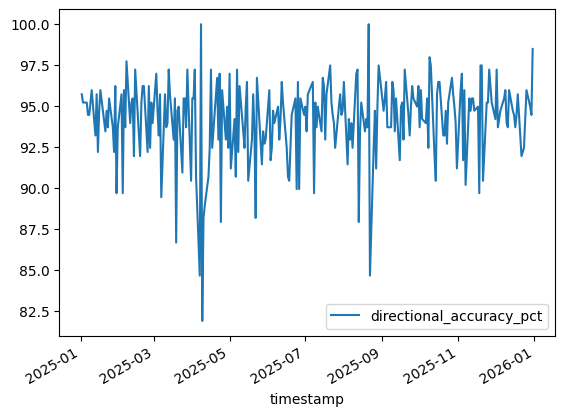

In [8]:
daily_prediction_summary.set_index('timestamp')[['directional_accuracy_pct']].plot()
plt.show()

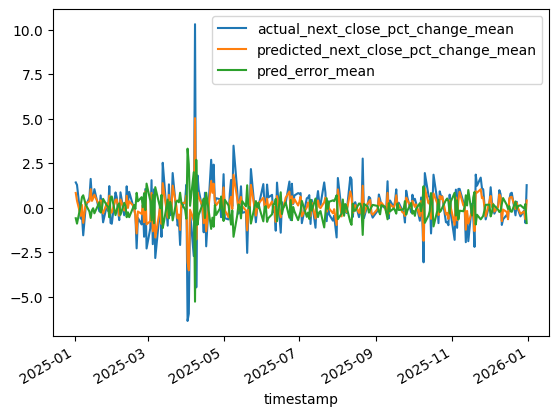

In [9]:
daily_prediction_summary.set_index('timestamp')[['actual_next_close_pct_change_mean', 'predicted_next_close_pct_change_mean', 'pred_error_mean']].plot()
plt.show()

In [11]:
zzz_df = results_df.copy()
zzz_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,...,close_lag1,close_lag2,return_lag1,next_close,next_close_change,next_close_change_pct,pred_next_close_change_pct,pred_error,abs_pred_error,directionally_correct
872,2025-01-02,AA,38.165,39.0400,37.9000,37.99,2703886.0,38.3283,33119.0,-0.004585,...,37.78,37.15,0.016958,35.71,-2.28,-6.001579,-1.20,4.801579,4.801579,1
873,2025-01-03,AA,37.950,37.9500,35.3752,35.71,7491799.0,35.9337,63814.0,-0.059025,...,37.99,37.78,0.005558,36.49,0.78,2.184262,0.38,-1.804262,1.804262,1
874,2025-01-06,AA,36.000,37.0750,35.9200,36.49,5983917.0,36.4794,58230.0,0.013611,...,35.71,37.99,-0.060016,36.24,-0.25,-0.685119,-0.00,0.685119,0.685119,0
875,2025-01-07,AA,36.890,37.3000,35.7550,36.24,3381466.0,36.2093,39434.0,-0.017620,...,36.49,35.71,0.021843,36.00,-0.24,-0.662252,-0.11,0.552252,0.552252,1
876,2025-01-08,AA,35.780,36.0300,34.7500,36.00,3775303.0,35.5672,41012.0,0.006149,...,36.24,36.49,-0.006851,35.91,-0.09,-0.250000,0.00,0.250000,0.250000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478297,2025-12-24,ZTS,123.100,125.6899,123.0600,125.49,2369020.0,125.1484,29115.0,0.019415,...,123.54,123.78,-0.001939,126.23,0.74,0.589688,0.41,-0.179688,0.179688,1
478298,2025-12-26,ZTS,125.160,126.3200,124.8000,126.23,3226934.0,125.8979,45295.0,0.008549,...,125.49,123.54,0.015784,125.98,-0.25,-0.198051,-0.14,0.058051,0.058051,1
478299,2025-12-29,ZTS,126.160,126.8500,125.5607,125.98,4465924.0,126.0785,51439.0,-0.001427,...,126.23,125.49,0.005897,126.41,0.43,0.341324,0.21,-0.131324,0.131324,1
478300,2025-12-30,ZTS,125.550,127.6000,125.4500,126.41,3230541.0,126.5667,45221.0,0.006850,...,125.98,126.23,-0.001981,125.82,-0.59,-0.466735,-0.33,0.136735,0.136735,1


In [13]:
raw_preds_df.columns

Index(['timestamp', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'vwap',
       'transactions', 'close_vs_open_pct', 'daily_high_vs_low_pct',
       'prev_day_return', 'SMA10', 'SMA20', 'SMA50', 'SMA100', 'RSI', 'MACD',
       'MACD_signal', 'MACD_hist', 'rolling_volatility', 'close_lag1',
       'close_lag2', 'return_lag1', 'next_close', 'pred_next_close',
       'pred_error', 'abs_pred_error'],
      dtype='object')